# Project Kiva: from laser points to a forge3d block

How one site in the [Project Kiva atlas](https://brooksgroves.com/project-kiva/) is made, start to finish, with the same code the atlas uses (`kiva/fetch.py`, `kiva/relief.py`, `kiva/imagery.py`, `kiva/render.py`). The default site is **Serpent Mound** in Ohio, a 411 m effigy about a metre high; set `SITE` to any id in `sites.yaml` to walk through another one.

1. The window, and the coordinate trap in the point-cloud archive
2. Streaming ground returns and gridding a bare-earth DTM
3. The relief views, and why a Local Relief Model makes a metre-high mound jump out
4. Checking the pins against the data
5. The aerial photo, for comparison
6. forge3d: the block as a museum specimen, from four sides

## Setup

This notebook streams points from the USGS 3DEP archive on AWS and aerial photos from Microsoft's Planetary Computer, so it needs the internet. The forge3d section needs Vulkan: a GPU, or Mesa's software driver under a virtual display on Linux.

```bash
pixi run -e notebook notebooks          # Jupyter Lab, with PDAL, rasterio and forge3d from pixi.toml
```

Or run **Actions → Run notebooks**, which executes it on GitHub's CPUs and commits it back with its outputs.

Settings come from environment variables, so the workflow can pass them without editing the notebook.

In [1]:
import os
SITE   = os.environ.get("KIVA_SITE", "serpent-mound")   # any id in sites.yaml
WIDTH  = int(os.environ.get("KIVA_WIDTH", "1280"))      # render width (16:9)
RENDER = os.environ.get("KIVA_RENDER", "1") == "1"      # 0 skips section 6 (no Vulkan needed)

In [2]:
import json, math, sys, time
from pathlib import Path

import numpy as np
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from pyproj import Transformer
from PIL import Image
from IPython.display import Image as Show, display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "kiva" / "cli.py").exists())
sys.path.insert(0, str(ROOT))
from kiva import cli, fetch, relief, render, imagery

%config InlineBackend.figure_formats = ["jpeg"]
%config InlineBackend.print_figure_kwargs = {"pil_kwargs": {"quality": 85}, "bbox_inches": "tight"}
plt.rcParams.update({"figure.dpi": 100, "font.size": 9})

site = cli.get_site(SITE)
work = cli.WORK / SITE
work.mkdir(parents=True, exist_ok=True)
print(f"{site['name']}, {site['place']}")
print(" ".join(site.get("about", site["blurb"]).split()))

Serpent Mound, Adams County, Ohio
The largest serpent effigy in the world: a low, winding mound 411 m long, with an oval at its head and a coiled tail, on a ridge above Brush Creek. Who built it, and when, is still argued over: some dates point to the Adena culture around 300 BCE, others to the Fort Ancient culture around 1070 CE. The head lines up with the summer-solstice sunset. The ridge it's on sits inside the Serpent Mound crater, an old structure about 14 km across that was probably made by a meteorite impact hundreds of millions of years ago. The Ohio History Connection runs the site, with a path all the way around and a viewing tower.


## 1. The window

Each site in `sites.yaml` is a rectangle: a centre, a size in metres, a grid cell, a projected CRS and the survey to read. `fetch.utm_bounds` snaps the window to the cell size.

The point-cloud archive is published as **Entwine Point Tiles**: an octree of points in a public S3 bucket, which PDAL can query for just the nodes inside a box. The trap: the octree is stored in **Web Mercator (EPSG:3857)**, not the survey's CRS. Ask with UTM bounds and you get zero points back, with no error.

In [3]:
x0, y0, x1, y1 = fetch.utm_bounds(site)
w, s, e, n = fetch.lonlat_bounds(site)
to3857 = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
mx0, my0 = to3857.transform(w, s)
mx1, my1 = to3857.transform(e, n)
print(f"window {x1 - x0:.0f} x {y1 - y0:.0f} m at {site['res']} m -> {(x1 - x0) / site['res']:.0f} x {(y1 - y0) / site['res']:.0f} cells")
print(f"  {site['crs']}:  x {x0:,.0f} .. {x1:,.0f}   y {y0:,.0f} .. {y1:,.0f}")
print(f"  EPSG:3857:   x {mx0:,.0f} .. {mx1:,.0f}   y {my0:,.0f} .. {my1:,.0f}   <- what the EPT reader wants")
print(f"  (the query is padded by 30 m; after reprojection the points are cropped to 20 m outside the window, and gridding trims to it)")
print(f"source: {site['source']}  {site.get('project', '')}")

window 560 x 520 m at 0.5 m -> 1120 x 1040 cells
  EPSG:26917:  x 289,322 .. 289,882   y 4,322,190 .. 4,322,710
  EPSG:3857:   x -9,287,849 .. -9,287,033   y 4,724,983 .. 4,725,752   <- what the EPT reader wants
  (the query is padded by 30 m; after reprojection the points are cropped to 20 m outside the window, and gridding trims to it)
source: ept  OH_StatewideP3_2_B21


## 2. Ground returns to a bare-earth DTM

A laser pulse is small enough to slip between leaves, so one pulse can record a branch, a lower branch and then the ground. Keep only the returns classified as **ground** (ASPRS class 2), grid them with inverse-distance weighting, and the trees and buildings are gone.

Cells with no ground return within 3 m stay empty (NaN). Those holes are where buildings, water or thick brush stood, and they're part of the evidence, so they're shown, not hidden.

This is the same branch `pixi run kiva build` takes; the DTM is kept in `data/sites/<id>/` and reused if it's already there.

  EPT OH_StatewideP3_2_B21: 83,355,038,835 points in the project


  2,287,450 ground returns in the window
2,287,450 ground returns from OH_StatewideP3_2_B21 (12 s)
6.8 ground returns per m² -> a 0.5 m cell holds about 1.7
DTM 1120 x 1040, 95.5% of cells have ground returns, elevation 202.9-241.5 m


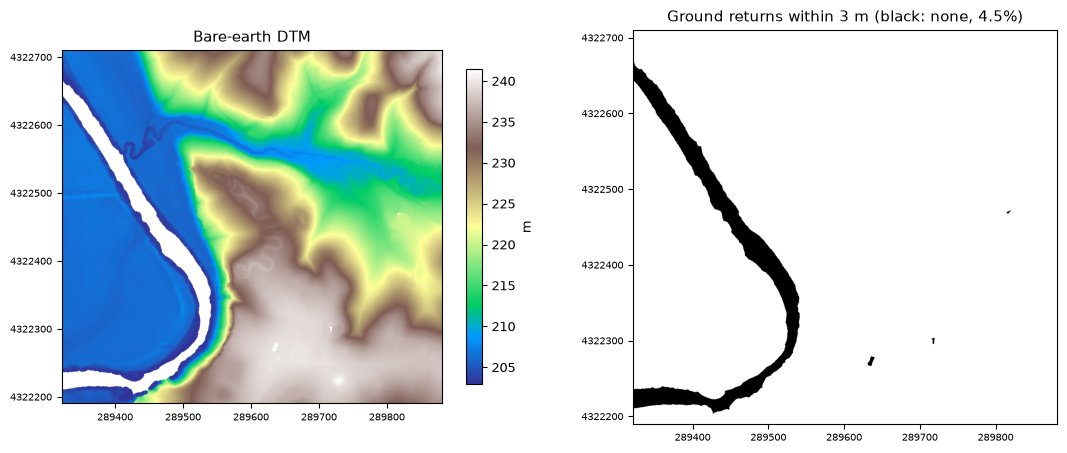

In [4]:
raw = work / "dtm_raw.tif"
prov_path = work / "provenance.json"
t0 = time.time()
if not raw.exists():
    if site["source"] == "ept":
        prov = fetch.fetch_ept(site, raw)
    else:
        prov = fetch.fetch_tnm(site, raw, work / "laz")
    prov_path.write_text(json.dumps(prov))
prov = json.loads(prov_path.read_text())
dtm, prof = fetch.read_dtm(raw)
res = site["res"]
area = (x1 - x0 + 40) * (y1 - y0 + 40)        # points are cropped 20 m outside the window
cover = float(np.isfinite(dtm).mean())
print(f"{prov['ground_points']:,} ground returns from {prov['project']} ({time.time() - t0:.0f} s)")
print(f"{prov['ground_points'] / area:.1f} ground returns per m² -> a {res} m cell holds about {prov['ground_points'] / area * res ** 2:.1f}")
print(f"DTM {dtm.shape[1]} x {dtm.shape[0]}, {cover:.1%} of cells have ground returns, "
      f"elevation {np.nanmin(dtm):.1f}-{np.nanmax(dtm):.1f} m")

ext = (x0, x1, y0, y1)
fig, axs = plt.subplots(1, 2, figsize=(11, 4.6))
im = axs[0].imshow(dtm, cmap="terrain", extent=ext)
plt.colorbar(im, ax=axs[0], shrink=0.8, label="m")
axs[0].set_title("Bare-earth DTM")
axs[1].imshow(np.isfinite(dtm), cmap="gray", extent=ext)
axs[1].set_title(f"Ground returns within 3 m (black: none, {1 - cover:.1%})")
for ax in axs:
    ax.ticklabel_format(useOffset=False, style="plain"); ax.tick_params(labelsize=7)
plt.tight_layout(); plt.show()

## 3. The relief views

A metre-high mound is lost next to a ridge tens of metres tall: ordinary shading is dominated by the big landforms. Each view in `kiva/relief.py` takes the big shape away in a different way:

- **Hillshade**: one sun. Familiar, and biased: anything parallel to the light disappears.
- **16-sun hillshade**: lit from 16 directions and averaged, so nothing hides in its own shadow.
- **Local relief model (LRM)**: the DTM minus a Gaussian-smoothed copy of itself (σ = 7.5 m). The landforms cancel and only bumps up to about 15 m across survive (after Hesse 2010).
- **Sky-view factor**: how much of the sky each cell can see within 10 m. Ditches and pits see less (Zakšek et al. 2011).
- **Negative openness**: the same horizon scan read as angles; hollows glow (Yokoyama et al. 2002).
- **Composite**: hillshade, slope, positive openness and sky-view blended with the VAT recipe (Kokalj & Somrak 2019). This is what's draped on the forge3d block.

relief products in 5 s


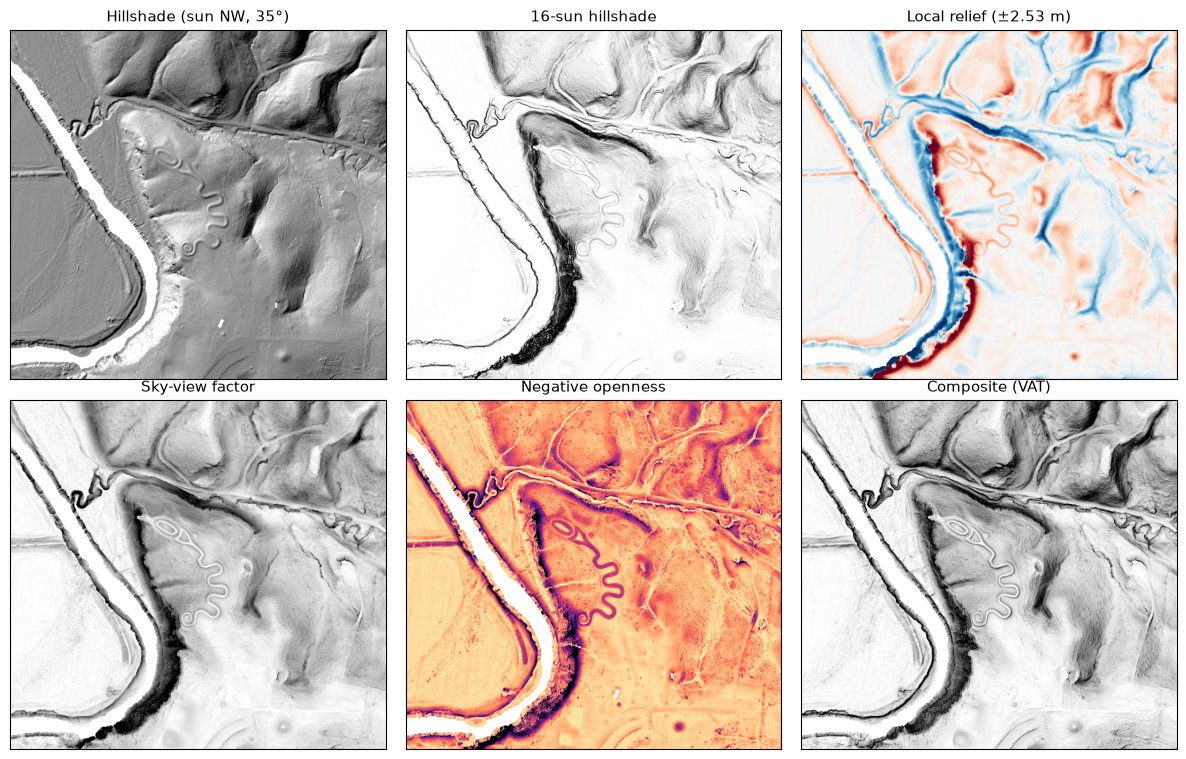

In [5]:
t0 = time.time()
prods = relief.all_products(dtm, res)
print(f"relief products in {time.time() - t0:.0f} s")

lrm = prods["lrm"]
lim = float(np.nanpercentile(np.abs(lrm), 99))
views = [("hillshade", "Hillshade (sun NW, 35°)", "gray", None),
         ("multi_hillshade", "16-sun hillshade", "gray", None),
         ("lrm", f"Local relief (±{lim:.2f} m)", "RdBu_r", TwoSlopeNorm(0, -lim, lim)),
         ("svf", "Sky-view factor", "gray", None),
         ("neg_openness", "Negative openness", "magma", None),
         ("composite", "Composite (VAT)", "gray", None)]
fig, axs = plt.subplots(2, 3, figsize=(12, 7.6))
for ax, (k, title, cmap, norm) in zip(axs.ravel(), views):
    a = prods[k]
    kw = {"norm": norm} if norm else {"vmin": np.nanpercentile(a, 1), "vmax": np.nanpercentile(a, 99)}
    ax.imshow(a, cmap=cmap, extent=ext, **kw)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

**Why the LRM works**, along one line. Here's a transect through the first pin: the DTM (the ground), the smoothed copy (the landform), and the difference between them (the local relief). The landform carries tens of metres; what's left over is the small stuff. The low banks just east of the pin, under a metre high, are the effigy at its head, and the big step about 40 m west is the edge of the bluff above Brush Creek.

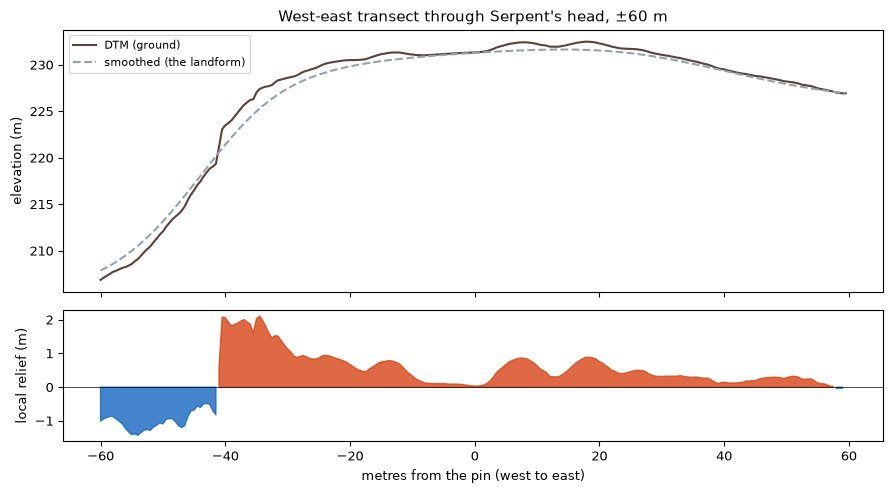

along this line: the ground spans 25.6 m; local relief spans -1.43 to +2.11 m


In [6]:
from scipy.ndimage import gaussian_filter
filled, _ = relief.fill_nodata(dtm)
smooth = gaussian_filter(filled, sigma=15.0 / res / 2.0)           # what local_relief() subtracts

f0 = site["features"][0]
to_crs = Transformer.from_crs("EPSG:4326", site["crs"], always_xy=True)
fx, fy = to_crs.transform(f0["lon"], f0["lat"])
row, col = rasterio.transform.rowcol(prof["transform"], fx, fy)
half = int(60 / res)
c0, c1 = max(col - half, 0), min(col + half, dtm.shape[1])
d = (np.arange(c0, c1) - col) * res

fig, (a1, a2) = plt.subplots(2, 1, figsize=(9, 5), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
a1.plot(d, filled[row, c0:c1], color="#5d4037", label="DTM (ground)")
a1.plot(d, smooth[row, c0:c1], color="#90a4ae", ls="--", label="smoothed (the landform)")
a1.set_ylabel("elevation (m)"); a1.legend(fontsize=8)
a1.set_title(f"West-east transect through {f0['name']}, ±60 m")
a2.axhline(0, color="k", lw=0.5)
a2.fill_between(d, 0, lrm[row, c0:c1], where=lrm[row, c0:c1] > 0, color="#d84315", alpha=0.8)
a2.fill_between(d, 0, lrm[row, c0:c1], where=lrm[row, c0:c1] < 0, color="#1565c0", alpha=0.8)
a2.set_ylabel("local relief (m)"); a2.set_xlabel("metres from the pin (west to east)")
plt.tight_layout(); plt.show()
seg = filled[row, c0:c1]
print(f"along this line: the ground spans {np.nanmax(seg) - np.nanmin(seg):.1f} m; "
      f"local relief spans {np.nanmin(lrm[row, c0:c1]):+.2f} to {np.nanmax(lrm[row, c0:c1]):+.2f} m")

## 4. Checking the pins

Every pin in `sites.yaml` was placed by finding the feature in the relief views, not by copying a gazetteer coordinate (several of the v1 pins were hundreds of metres to kilometres off). As a cheap extra check, each build records the highest points in the window; at Cahokia, the highest one lands on Monks Mound. Here are this site's pins on the local relief, with the highest points marked.

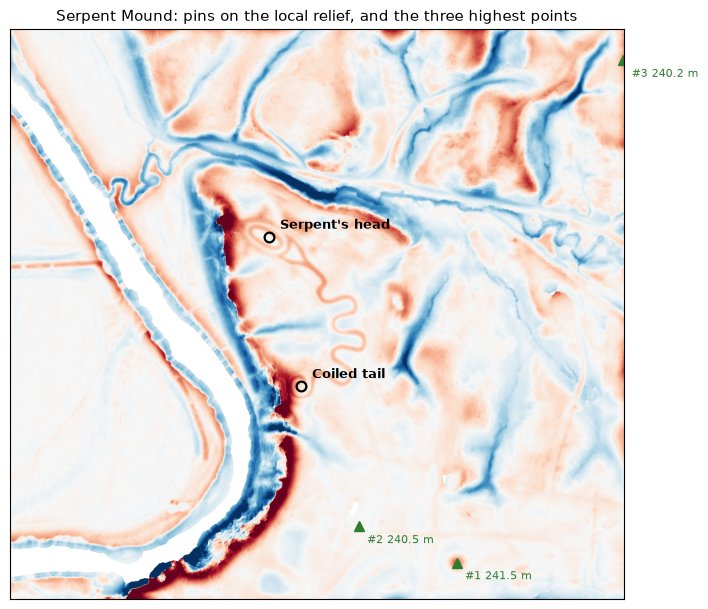

highest #1: 241.5 m at 39.023787, -83.428959
highest #2: 240.5 m at 39.024062, -83.430002
highest #3: 240.2 m at 39.027951, -83.427346


In [7]:
peaks = cli.highest(dtm, prof, res)
fig, ax = plt.subplots(figsize=(8, 7.4))
ax.imshow(lrm, cmap="RdBu_r", norm=TwoSlopeNorm(0, -lim, lim), extent=ext)
for f in site["features"]:
    x, y = to_crs.transform(f["lon"], f["lat"])
    ax.plot(x, y, "o", ms=7, mfc="none", mec="k", mew=1.6)
    ax.annotate(f["name"], (x, y), xytext=(8, 6), textcoords="offset points", fontsize=9, weight="bold")
for i, (lat, lon, z) in enumerate(peaks, 1):
    x, y = to_crs.transform(lon, lat)
    ax.plot(x, y, "^", color="#2e7d32", ms=7)
    ax.annotate(f"#{i} {z:.1f} m", (x, y), xytext=(6, -12), textcoords="offset points", fontsize=8, color="#2e7d32")
ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f"{site['name']}: pins on the local relief, and the three highest points")
plt.show()
for i, p in enumerate(peaks, 1):
    print(f"highest #{i}: {p[2]:.1f} m at {p[0]:.6f}, {p[1]:.6f}")

## 5. From the air

USDA NAIP aerial photography from the Planetary Computer, reprojected onto exactly the same grid as the DTM (newest year first, older years fill any gaps). It's draped on the second forge3d block so the two can be compared from the same camera: what you'd see from a plane, and what's under it.

  NAIP [2023]: 100.0% covered


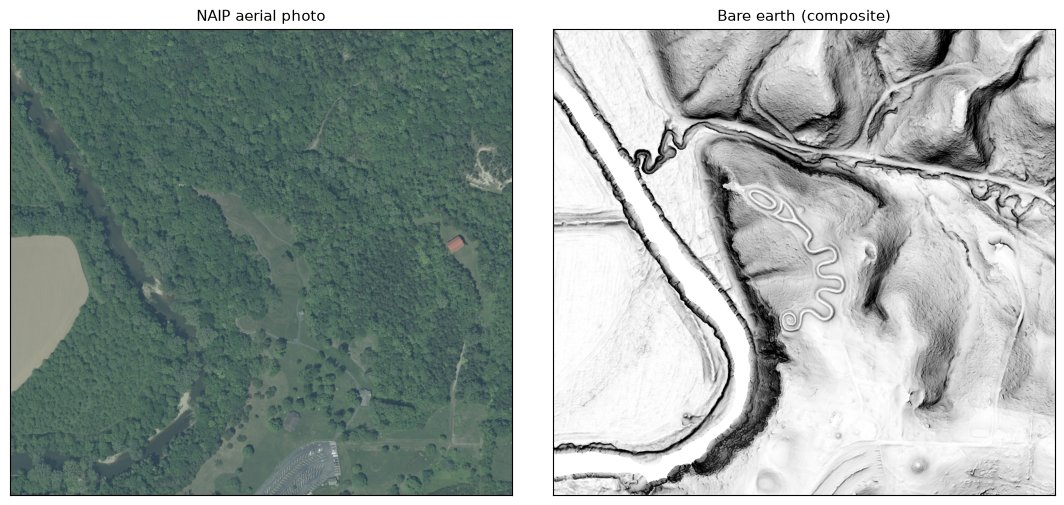

In [8]:
naip_p = work / "naip.npy"
if naip_p.exists():
    photo = np.load(naip_p)
else:
    photo, year = imagery.naip(site, prof["transform"], dtm.shape)
    if photo is not None:
        np.save(naip_p, photo)
if photo is not None:
    fig, axs = plt.subplots(1, 2, figsize=(11, 5))
    axs[0].imshow(photo, extent=ext); axs[0].set_title("NAIP aerial photo")
    axs[1].imshow(prods["composite"], cmap="gray", extent=ext, vmin=np.nanpercentile(prods["composite"], 1),
                  vmax=np.nanpercentile(prods["composite"], 99)); axs[1].set_title("Bare earth (composite)")
    for ax in axs: ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout(); plt.show()
else:
    print("no NAIP over this window")

## 6. forge3d: the block

`kiva/render.py` turns the window into a museum specimen:

- **The mesh.** forge3d's terrain viewer meshes at most 2048 vertices across. Windows bigger than that are averaged down to fit; this one is checked below. The mesh gets a very light blur (σ = 0.6 cells) so cliffs don't stair-step.
- **The drape.** The relief composite is tinted from umber to bone, so it reads as earth rather than a printout, and loaded as an overlay. The NAIP photo gets its own viewer with the same camera.
- **The light.** PBR shading with a 4096² shadow map, height-based ambient occlusion and soft sun visibility, from a low sun in the site's `sun_az` / `sun_el`: the raking light archaeologists wait for. The vertical exaggeration is the site's `zscale`.
- **The cut-out.** The block's outline is projected from the DEM with the same camera maths as the viewer, so it can be lifted onto a dark backdrop with a soft contact shadow, and the pins land on the ground.

render DEM 1120 x 1040 (full resolution), zscale 3, sun 300° / 18°


relief, photo rendered in 16 s


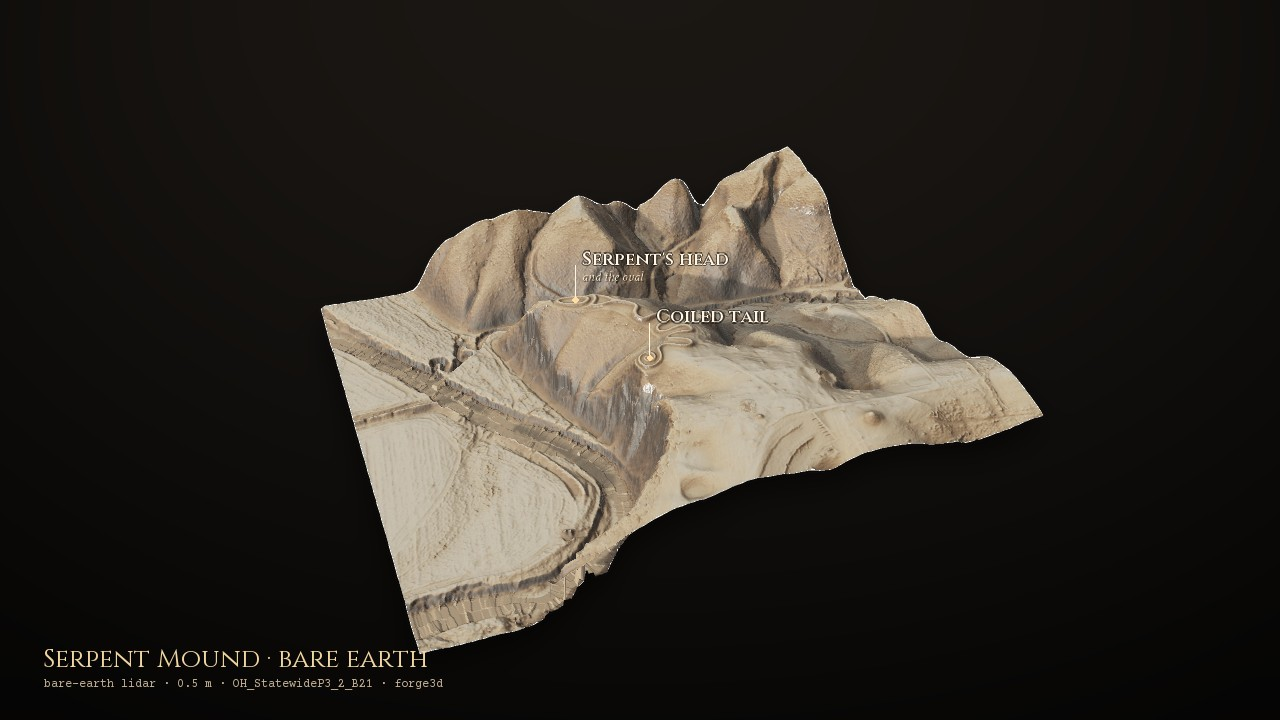

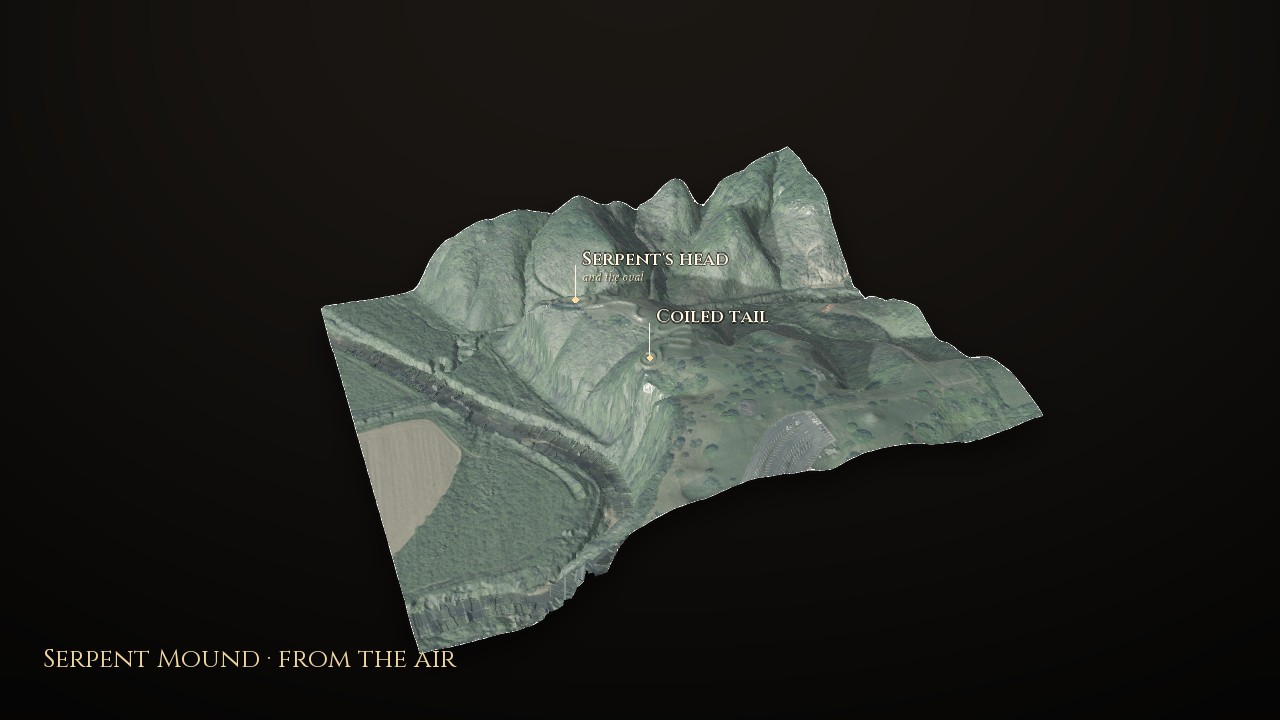

In [9]:
if RENDER:
    size = (WIDTH, WIDTH * 9 // 16)
    rdir = render.prepare(work, {"composite": prods["composite"]}, filled, prof, photo)
    block = render.Block(rdir, site)
    with rasterio.open(rdir / "dem.tif") as s_:
        print(f"render DEM {s_.width} x {s_.height} ({'full resolution' if max(dtm.shape) <= render.MAX_GRID else 'averaged to fit the 2048 cap'}), "
              f"zscale {block.zs:g}, sun {site.get('sun_az', 315)}° / {site.get('sun_el', 22)}°")
    out = work / "nb"
    t0 = time.time()
    made = render.stills(block, out, size, credit=f"bare-earth lidar · {res:g} m · {prov['project']} · forge3d")
    print(f"{', '.join(made)} rendered in {time.time() - t0:.0f} s")
    for m in made:
        display(Show(filename=str(out / f"{m}.jpg"), width=WIDTH))

**From four sides.** The atlas's orbit video is one slow turn around the block (`render.orbit`, 14 s at 30 fps, rendered in parallel chunks on Actions). Here are four frames of it, a quarter-turn apart, from one viewer.

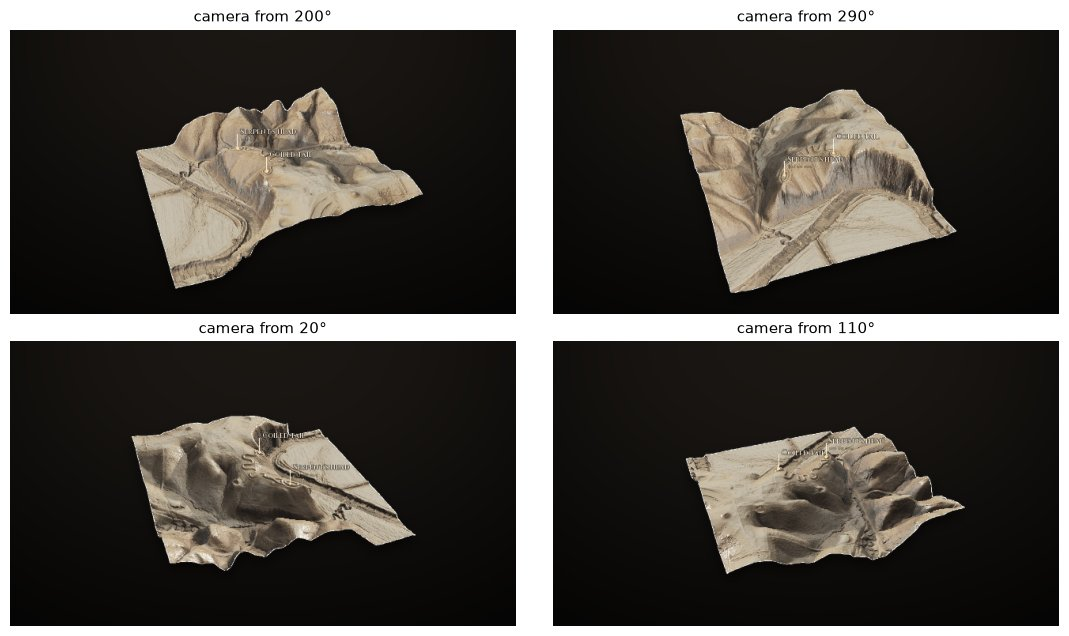

In [10]:
if RENDER:
    small = (WIDTH // 2, WIDTH // 2 * 9 // 16)
    phi0 = float(site.get("view_az", 200))
    v = render.Viewer(block, "relief.png", small, render.FOV)
    frames = []
    try:
        for q in range(4):
            phi = phi0 + 90 * q
            eye = block.eye(phi, render.ELEV, small, render.FOV)
            p = out / f"_orbit_{q}.png"
            v.shot(eye, block.target, render.FOV, p)
            im = render.finish(p, render.silhouette(block, eye, block.target, render.FOV, small))
            render.pins(im, block, eye, block.target, render.FOV, small, site.get("features", []))
            frames.append((phi % 360, im)); p.unlink()
    finally:
        v.close()
    fig, axs = plt.subplots(2, 2, figsize=(11, 6.4))
    for ax, (phi, im) in zip(axs.ravel(), frames):
        ax.imshow(im); ax.set_title(f"camera from {phi:.0f}°"); ax.axis("off")
    plt.tight_layout(); plt.show()

The full orbit for every site is in `sites/<id>/orbit.mp4`, and the atlas is at [brooksgroves.com/project-kiva](https://brooksgroves.com/project-kiva/).

Data: [USGS 3DEP](https://www.usgs.gov/3d-elevation-program) point clouds via the [AWS open data archive](https://registry.opendata.aws/usgs-lidar/) and The National Map; USDA NAIP via [Microsoft Planetary Computer](https://planetarycomputer.microsoft.com/). Rendering: [forge3d](https://github.com/milos-agathon/forge3d) by Milos Popovic.